## 2022 Pre-doc Data Task
#### Gavin Qu, March 6th 2026

This is an exercise that will test your ability to work with large datasets to draw interesting conclusions and present results in a compelling way. You will be working with the Social Connectedness Index (SCI), a dataset built from an anonymized snapshot of Facebook users and their friendship networks. The data measure the intensity of social connections between counties.

Relevant data: `county_county_sci.tsv`, `sf12010countydistancemiles.csv`.

Our team has a presentation coming up to a set of policymakers in Washtenaw County, Michigan. Using the SCI and the county distance datasets, make a set of exploratory plots describing the social connections of Washtenaw County. Specifically: 

In [27]:
import pandas as pd
import numpy as np

df1 = pd.read_csv("./data/Part1/county_county_sci.tsv", sep='\t')
df2 = pd.read_csv("./data/Part1/sf12010countydistancemiles.csv")

In [28]:
print(f"Shape of df1: {df1.shape}")
print(f"Shape of df2: {df2.shape}")

Shape of df1: (10426441, 3)
Shape of df2: (10371620, 3)


**(a)** Summarize the distribution of Washtenaw's Social Connectedness Index to other counties. County FIPS: 26161

df1 contains user location, friend location, and social connect index between counties, while df2 contains the distance between each user to their friend's counties and distance. Looking at the mi_to_county column, mean is at 952 miles with min at 1.4 miles and max at 6273 miles distance from Washtenaw county, the median is at 806 miles, standard deviation of 655 miles. Over half of all 10 million records are unique values indicating those are out of the county connections. 

Distribution of Washtenau's SCI to other counties: mean score of 4861, standard deviation of 43914, median of 1933

Plot: Since scaled SCI is a continuous variable I would use kde plot overlay on top of a histogram, since x will be skewed. 

In [ ]:
mask = df1['user_loc'] == 26161
df_part_a = df1.loc[mask, :]

print("\nDistribution of social connected index:\n")
print(df_part_a.describe())

Shape of df1: (10426441, 3)
Shape of df2: (10371620, 3)

Distribution of social connected index:

       user_loc        fr_loc    scaled_sci
count    3229.0   3229.000000  3.229000e+03
mean    26161.0  31514.364819  4.861666e+03
std         0.0  16403.343322  4.391460e+04
min     26161.0   1001.000000  8.200000e+01
25%     26161.0  19039.000000  1.278000e+03
50%     26161.0  30035.000000  1.933000e+03
75%     26161.0  46123.000000  3.020000e+03
max     26161.0  78030.000000  2.345513e+06


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

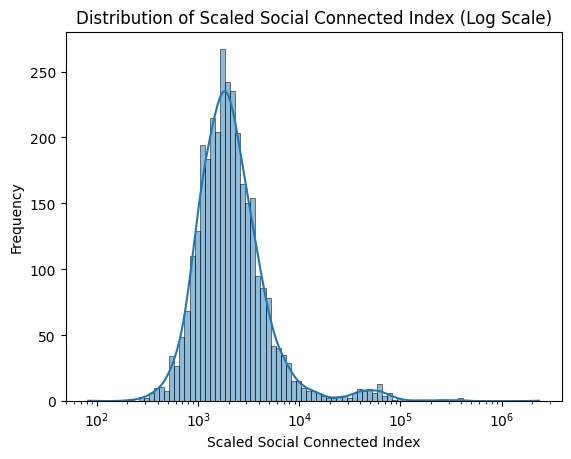

In [39]:
sns.histplot(data=df_part_a, x='scaled_sci', bins='auto', log_scale=True, kde=True)
plt.title('Distribution of Scaled Social Connected Index (Log Scale)')
plt.xlabel('Scaled Social Connected Index')
plt.ylabel('Frequency')
plt.show()

**(b)** Which counties are most strongly connected to Washtenaw? 

In [ ]:
# TODO: find top 10 connected using df_part_a

# TODO: map to county name using county_description dataset using FIPS code

**(c)** Merge in the distance data and describe the relationship between distance to Washtenaw and connectedness to Washtenaw.

The team is also interested in exploring the relationship between a county's network concentration—e.g., the share of a county's Facebook friends that are located nearby—and other important socio-economic measures. For this part: 

**(d)** Using the `county_county_sci.tsv` and `sfl2010countydistancemiles.csv`, construct a county-level measure of network concentration. Briefly justify your measure (there is no single "right" answer). Remember that the social connectedness index is defined as:

$$Social\ Connectedness\ Index_{i,j} = \frac{FB\_Connections_{i,j}}{FB\_Users_{i} \times FB\_Users_{j}}$$

**(e)** Merge in the `county_demographics` dataset and describe relationships between network concentration and 2-3 other county level measures. Suggest possible explanations of why these relationships might exist. Discuss any ideas you have on how your explanations could be tested (perhaps using other data or in other contexts).

Data Dictionary 

1. county_county_sci.tsv 

This is the Facebook Social Connectedness Index (SCI). A full description of the data is available here. We include the "US Counties - US Counties" data, a symmetric measure between every pair of US counties. The original data can be found here. The columns are: 

`user_loc` = The FIPS code of the first county (the user's county).

`fr_loc` = The FIPS code of the second county (the friend's county).

`scaled_sci` = The (symmetric) Social Connectedness Index between counties, as detailed in the full description document linked to above.

2. sf12010countydistancemiles.csv 

This is the distance between every county pair (from the NBER). Important: the county pairs between a county and itself are excluded. The columns are: 

`county1` = The FIPS code of the first county.

`omi_to_county` = Miles between the centers countyl and county2.

`county2` = The FIPS code of the second county.

3. county_description.csv 

This is a set of simple county descriptors. The columns are: 

`county_fips` = County FIPS code.

`county_name` = County name.

`state_fips` = State FIPS code.

`state_name` = State name.

`state_abrev` = State abbreviation.

4. county_demographics.csv 

This is a set of county-level demographics and socio-economic outcomes from Bailey et al., 2018. The columns are `county_fips`, `measure`, and `value`. `measure` is one of: 

`no_highschool` = The share of the population that did not attend high school.

`total_population` = The total population.

`male_population` = The male population.

`median_age` = The median age.

`pct_white_alone` = The share of the population that is White alone.

`median_hh_income` = The median household income.

`mean_hh_income` = The mean household income.

`share_below_povline` = The share of the population below the poverty line.

`obama_share_vs_mccain` = Of those who voted for Obama or McCain for president in 2008, the share that voted for Obama.

`cz` = The commuting zone this county falls within.

`e_rank_b` = A measure of upward mobility (i.e., how likely it is for you to have a higher income than your parents). Higher values mean more upward mobility. From Chetty et al. 2020.

`frac_kteenbirthfem` = The teen birth rate.

`sk97` = A measure of social capital (i.e., the general strength of the relationships and trust of people in a county). From Rupasingha et al. 2006.

`le_agg_q[X]_[Y]` = For people of gender Y in this county with incomes in quarter X of the national income distribution, their life expectancy.